Importing libraries and creating folders

In [42]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.loader import load_files
from src.config import EVENTS, SENSORS

from pathlib import Path

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

Loading data

In [43]:
df = load_files(max_files_per_event=5)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
df.head()

  [0] Normal: Loaded 5 files
  [3] DHSV Failure: Loaded 5 files
  [4] Severe Slugging: Loaded 5 files
  [7] Scaling PCK: Loaded 5 files
  [9] Hydrate: Loaded 0 files
Rows: 688,923
Columns: ['T-TPT', 'P-TPT', 'P-PDG', 'P-MON-CKP', 'T-JUS-CKP', 'label', 'event_type', 'source']


,T-TPT,P-TPT,P-PDG,P-MON-CKP,T-JUS-CKP,label,event_type,source
0,119.0781,10074540.0,0.0,1627884.0,84.64463,0,0,WELL-00001_20170201010207.parquet
1,119.0781,10074540.0,0.0,1633397.0,84.63828,0,0,WELL-00001_20170201010207.parquet
2,119.0781,10074540.0,0.0,1638909.0,84.63194,0,0,WELL-00001_20170201010207.parquet
3,119.0781,10074540.0,0.0,1644422.0,84.62558,0,0,WELL-00001_20170201010207.parquet
4,119.0781,10074540.0,0.0,1649934.0,84.61923,0,0,WELL-00001_20170201010207.parquet


Base statistics

In [44]:
print("=== Label distribution ===")
print(df["label"].value_counts())

print("\n=== By event type ===")
for eid, count in df["event_type"].value_counts().items():
    print(f"  {eid} {EVENTS[eid]:<20}: {count:>8,} rows")

print("\n=== Empty rows (%) ===")
print((df[SENSORS].isnull().mean() * 100).round(1))

=== Label distribution ===
label
1    467620
0    221303
Name: count, dtype: int64

=== By event type ===
  7 Scaling PCK         :  420,238 rows
  3 DHSV Failure        :  107,547 rows
  0 Normal              :  107,381 rows
  4 Severe Slugging     :   53,757 rows

=== Empty rows (%) ===
T-TPT        0.0
P-TPT        0.0
P-PDG        0.0
P-MON-CKP    0.0
T-JUS-CKP    0.0
dtype: float64


Balancing classes

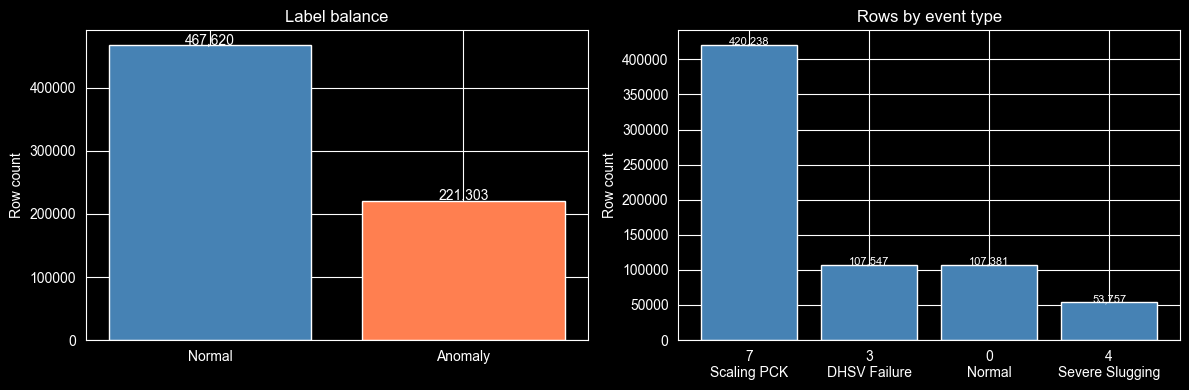

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Норма vs Аномалия
ax = axes[0]
counts = df["label"].value_counts()
bars = ax.bar(["Normal", "Anomaly"], counts.values, color=["steelblue", "coral"])
ax.set_title("Label balance")
ax.set_ylabel("Row count")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{val:,}", ha="center", fontsize=10)

ax = axes[1]
event_counts = df["event_type"].value_counts()
event_labels = [f"{eid}\n{EVENTS[eid]}" for eid in event_counts.index]
bars = ax.bar(event_labels, event_counts.values, color="steelblue")
ax.set_title("Rows by event type")
ax.set_ylabel("Row count")
for bar, val in zip(bars, event_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{val:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/class_balance.png", dpi=150)
plt.show()

Sensor rearranging

C:\Users\Timur\PycharmProjects\DatasetViewer\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


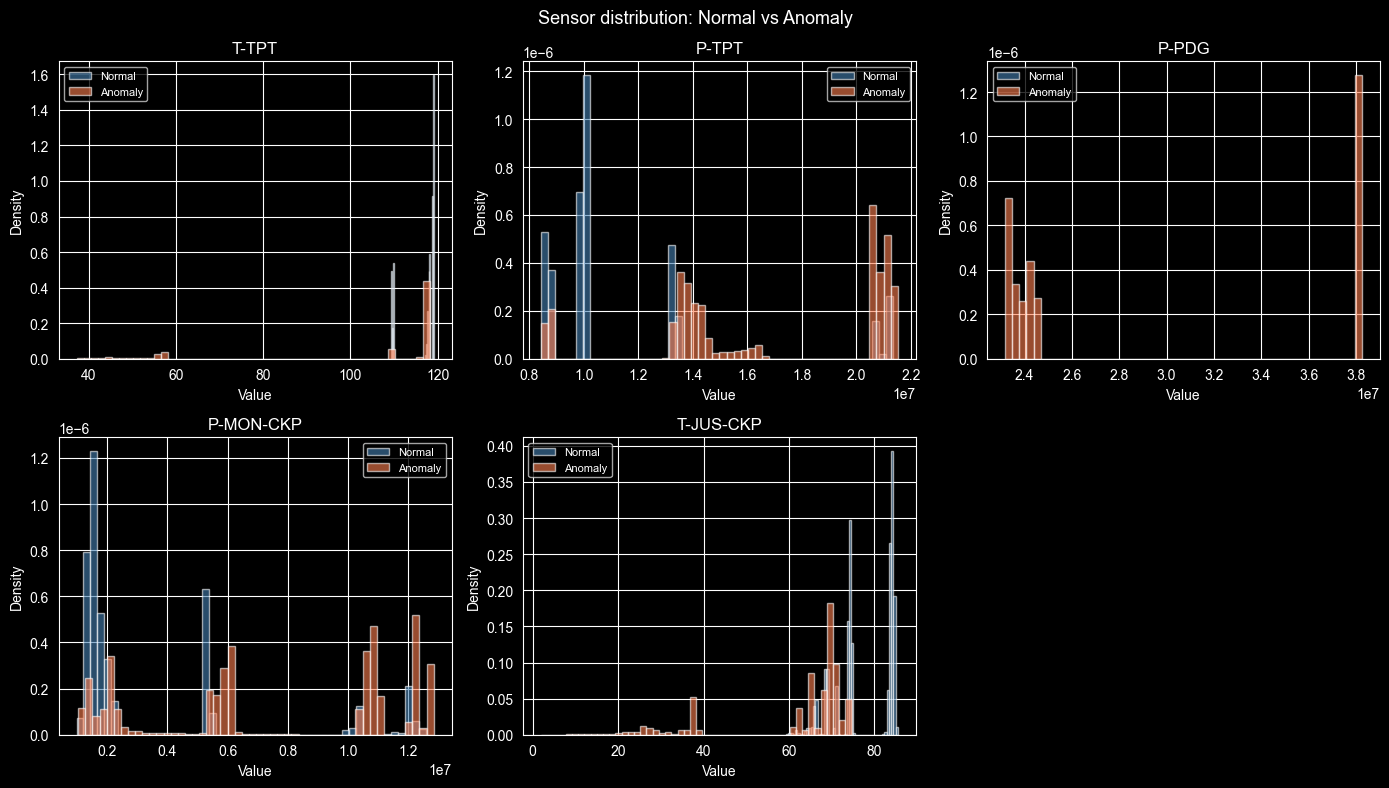

In [46]:
from src.config import SENSORS

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(SENSORS):
    ax = axes[i]

    normal = df[df["label"] == 0][col].dropna()
    anomaly = df[df["label"] == 1][col].dropna()

    if col == "P-PDG":
        normal = normal[normal > 0]
        anomaly = anomaly[anomaly > 0]

    ax.hist(normal, bins=50, alpha=0.6, color="steelblue", label="Normal", density=True)
    ax.hist(anomaly, bins=50, alpha=0.6, color="coral", label="Anomaly", density=True)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Sensor distribution: Normal vs Anomaly", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/sensor_distributions.png", dpi=150)
plt.show()

Time-table for one anomaly file

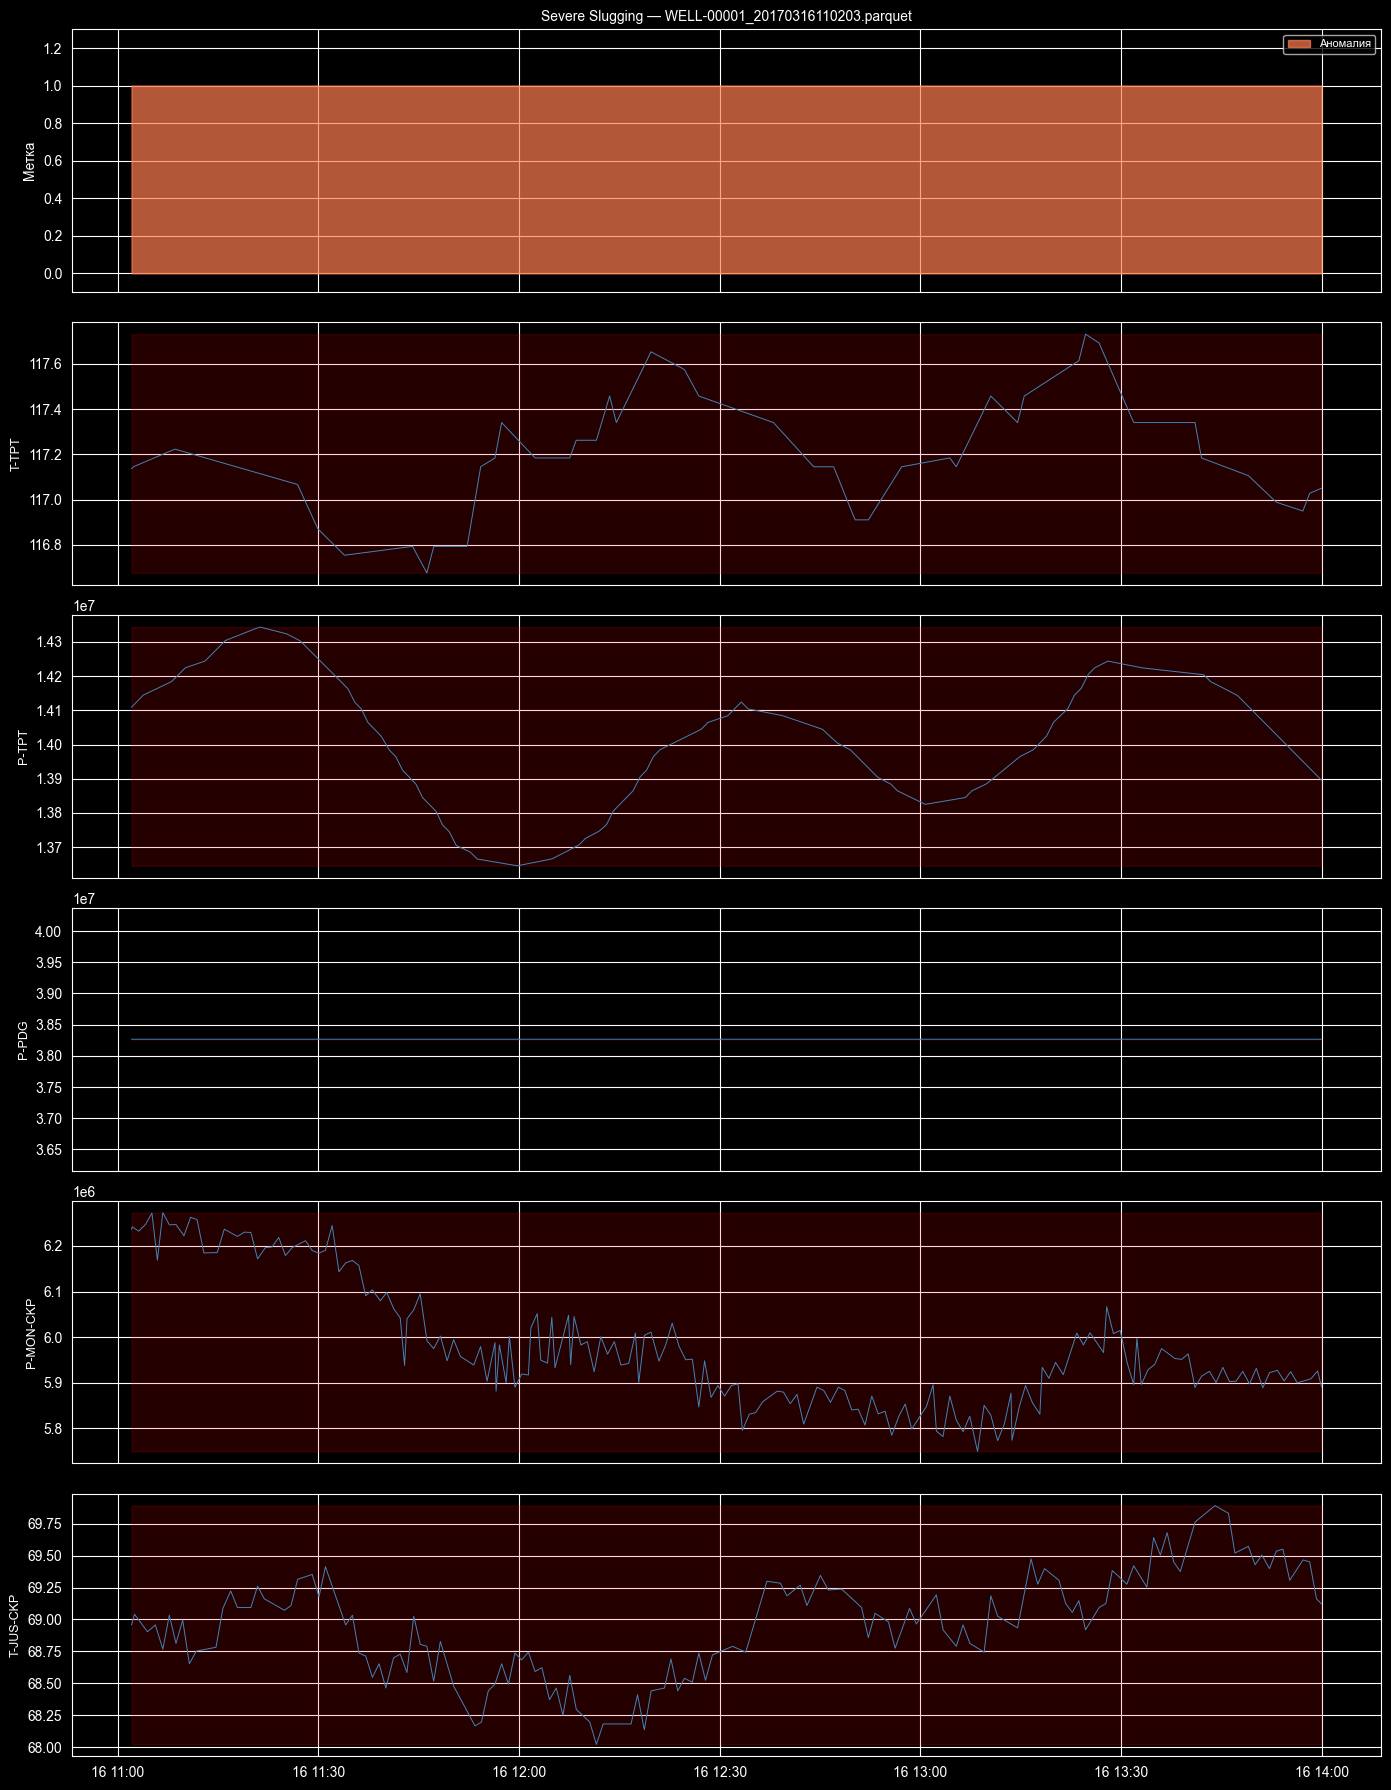

In [47]:
from src.config import DATA_DIR

# Берём реальный файл с аномалией события 4
sample_file = [f for f in sorted((DATA_DIR / "4").glob("*.parquet"))
               if not f.name.startswith(("DRAWN", "SIMULATED"))][0]

df_sample = pd.read_parquet(sample_file)
df_sample = df_sample.ffill().bfill()
df_sample["label"] = (df_sample["class"].fillna(0).astype(int) > 0).astype(int)

working = [c for c in SENSORS if c in df_sample.columns
           and df_sample[c].isnull().mean() < 0.5]

fig, axes = plt.subplots(len(working) + 1, 1,
                         figsize=(14, 3 * (len(working) + 1)),
                         sharex=True)

# Метки сверху
axes[0].fill_between(df_sample.index,
                     0, df_sample["label"],
                     alpha=0.7, color="coral", label="Аномалия")
axes[0].set_ylabel("Метка")
axes[0].set_ylim(-0.1, 1.3)
axes[0].legend(fontsize=8)
axes[0].set_title(f"Severe Slugging — {sample_file.name}", fontsize=10)

for ax, col in zip(axes[1:], working):
    ax.plot(df_sample.index, df_sample[col], linewidth=0.7, color="steelblue")
    ax.fill_between(df_sample.index,
                    df_sample[col].min(), df_sample[col].max(),
                    where=(df_sample["label"] == 1),
                    alpha=0.15, color="red")
    ax.set_ylabel(col, fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/timeseries_example.png", dpi=150)
plt.show()

In [48]:
from src.config import DATA_DIR, SENSORS

# Смотрим реальные файлы события 9
folder = DATA_DIR / "9"
real_files = [f for f in sorted(folder.glob("*.parquet"))
              if not f.name.startswith(("DRAWN", "SIMULATED"))]

print(f"Real files in event 9: {len(real_files)}")

for f in real_files[:3]:
    df = pd.read_parquet(f)
    available = [c for c in SENSORS if c in df.columns]
    coverage = {c: f"{df[c].isnull().mean()*100:.0f}%"
                for c in SENSORS if c in df.columns}
    missing = [c for c in SENSORS if c not in df.columns]
    print(f"\n{f.name}")
    print(f"  Covered: {coverage}")
    print(f"  Missing fully: {missing}")

Real files in event 9: 57

WELL-00010_20180517000402.parquet
  Covered: {'T-TPT': '0%', 'P-TPT': '100%', 'P-PDG': '100%', 'P-MON-CKP': '0%', 'T-JUS-CKP': '100%'}
  Missing fully: []

WELL-00010_20180715083053.parquet
  Covered: {'T-TPT': '0%', 'P-TPT': '100%', 'P-PDG': '100%', 'P-MON-CKP': '0%', 'T-JUS-CKP': '100%'}
  Missing fully: []

WELL-00010_20180717234051.parquet
  Covered: {'T-TPT': '0%', 'P-TPT': '100%', 'P-PDG': '100%', 'P-MON-CKP': '0%', 'T-JUS-CKP': '100%'}
  Missing fully: []


Normalization

In [49]:
import sys
sys.path.append("..")

from src.preprocessor import load_and_normalize, print_normalization_stats

SCALER_PATH = "../outputs/models/scaler.pkl"

print("Loading and normalizing data...")
df_norm, scaler = load_and_normalize(
    max_files_per_event=10,
    min_sensors=2,
    fit_scaler=True,
    scaler_path=SCALER_PATH,
)

print(f"\nTotal rows: {len(df_norm):,}")
print_normalization_stats(df_norm)

Loading and normalizing data...
  [0] Normal: Loaded 10 files
  [3] DHSV Failure: Loaded 10 files
  [4] Severe Slugging: Loaded 10 files
  [7] Scaling PCK: Loaded 10 files
  [9] Hydrate: Loaded 10 files
Scaler обучен на нормальных данных
Scaler сохранён: ../outputs/models/scaler.pkl

Total rows: 3,653,142
=== Статистика после нормализации ===
(среднее ~0, std ~1 — если всё хорошо)

      T-TPT  P-TPT  P-PDG  P-MON-CKP  T-JUS-CKP
mean  0.236  0.443 -0.250      0.205      0.159
std   0.735  0.817  1.545      1.176      0.590
min  -3.029 -1.434 -5.969     -1.887     -1.632
max   0.879  2.606  0.168      4.775      1.248


Normalization visualization

C:\Users\Timur\PycharmProjects\DatasetViewer\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


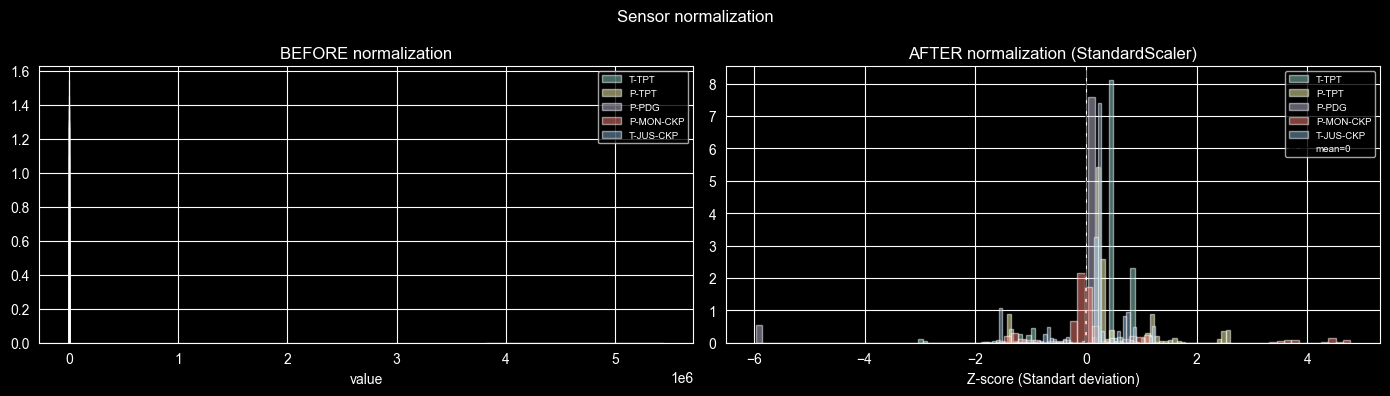

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ДО нормализации (из df который уже загружен)
ax = axes[0]
for col in SENSORS:
    vals = df[col].dropna()
    if col == "P-PDG":
        vals = vals[vals > 0]
    ax.hist(vals, bins=50, alpha=0.5, label=col, density=True)
ax.set_title("BEFORE normalization")
ax.set_xlabel("value")
ax.legend(fontsize=7)

# ПОСЛЕ нормализации
ax = axes[1]
for col in SENSORS:
    ax.hist(df_norm[col], bins=50, alpha=0.5, label=col, density=True)
ax.set_title("AFTER normalization (StandardScaler)")
ax.set_xlabel("Z-score (Standart deviation)")
ax.axvline(x=0, color="black", linestyle="--", alpha=0.5, label="mean=0")
ax.legend(fontsize=7)

plt.suptitle("Sensor normalization", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/normalization.png", dpi=150)
plt.show()

Saving

In [41]:
PROCESSED_PATH = "../outputs/processed_data.parquet"

df_norm.to_parquet(PROCESSED_PATH, index=False)
print(f"Data saved: {PROCESSED_PATH}")
print(f"File size: {Path(PROCESSED_PATH).stat().st_size / 1024 / 1024:.1f} MB")

Data saved: ../outputs/processed_data.parquet
File size: 39.5 MB
